<a href="https://colab.research.google.com/github/Joacoromero06/Estadistica-Descriptiva/blob/main/1_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

<BarContainer object of 6 artists>

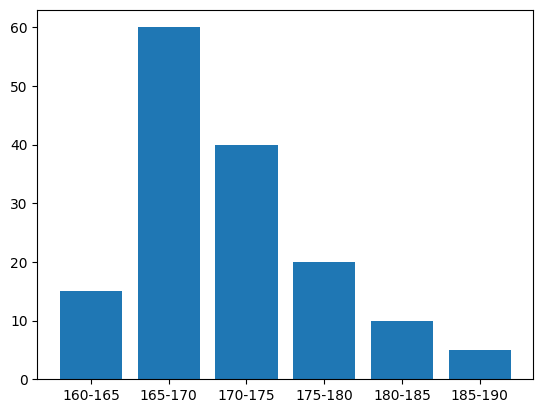

In [ ]:
D = {
    '160-165': 15,
    '165-170': 60,
    '170-175': 40,
    '175-180': 20,
    '180-185': 10,
    '185-190': 5
}
plt.bar(D.keys(), D.values())

In [ ]:
amplitud = 5 # asi nos dieron los datos
extremos = [i for i in range(160, 190+1, amplitud)]
df = pd.DataFrame({
    'Marca de Clase': [(extremos[i]+extremos[i+1])/2 for i in range(len(extremos)-1)],
    'Frecuencia. (fi)': D.values()
})
df['Frecuencia Acumulada. (fac)'] = df['Frecuencia. (fi)'].cumsum()
N = df['Frecuencia. (fi)'].sum(); df['Frecuencia Relativa. (fr)'] = df['Frecuencia. (fi)'] / N
df['Frecuencia Relativa Acumulada. (fr ac)'] = df['Frecuencia Relativa. (fr)'].cumsum()
df.interpolate()

,Marca de Clase,Frecuencia. (fi),Frecuencia Acumulada. (fac),Frecuencia Relativa. (fr),Frecuencia Relativa Acumulada. (fr ac)
0,162.5,15,15,0.100000,0.100000
1,167.5,60,75,0.400000,0.500000
2,172.5,40,115,0.266667,0.766667
3,177.5,20,135,0.133333,0.900000
4,182.5,10,145,0.066667,0.966667
5,187.5,5,150,0.033333,1.000000


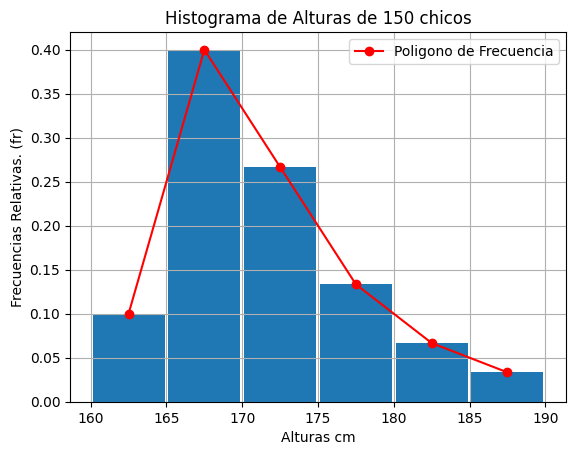

In [ ]:
fig1, ax1 = plt.subplots()

ax1.bar(df['Marca de Clase'], df['Frecuencia Relativa. (fr)'], width=amplitud*0.95)
ax1.plot(df['Marca de Clase'], df['Frecuencia Relativa. (fr)'], color='red', marker='o', label='Poligono de Frecuencia')

ax1.set_xlabel('Alturas cm'); ax1.set_ylabel('Frecuencias Relativas. (fr)'); ax1.set_title('Histograma de Alturas de 150 chicos'); ax1.legend(); ax1.grid()

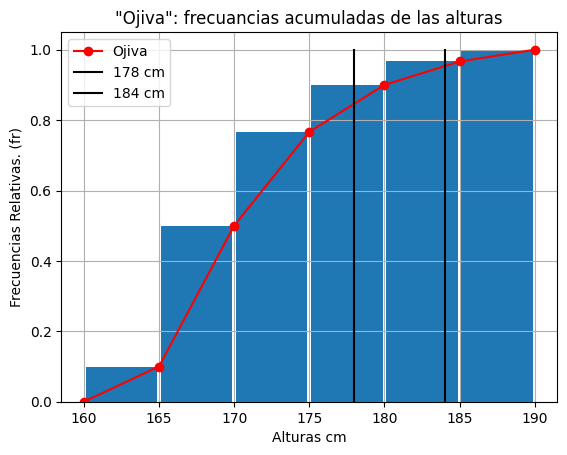

In [ ]:
fig2, ax2 = plt.subplots()

ax2.bar(df['Marca de Clase'], df['Frecuencia Relativa Acumulada. (fr ac)'], width=0.95*amplitud)
ojiva_x, ojiva_y = extremos, [0]+list(df['Frecuencia Relativa Acumulada. (fr ac)'])
ax2.plot(ojiva_x, ojiva_y, color='red', marker='o', label='Ojiva')

ax2.plot([178]*30, np.linspace(0,1, 30), color='black', label='178 cm')
ax2.plot([184]*30, np.linspace(0,1, 30), color='black', label='184 cm')

ax2.set_xlabel('Alturas cm'); ax2.set_ylabel('Frecuencias Relativas. (fr)'); ax2.set_title('\"Ojiva\": frecuancias acumuladas de las alturas'); ax2.legend(); ax2.grid()

In [ ]:
print(ojiva_x, ojiva_y)

[160, 165, 170, 175, 180, 185, 190] [0, 0.1, 0.5, 0.7666666666666666, 0.8999999999999999, 0.9666666666666666, 0.9999999999999999]


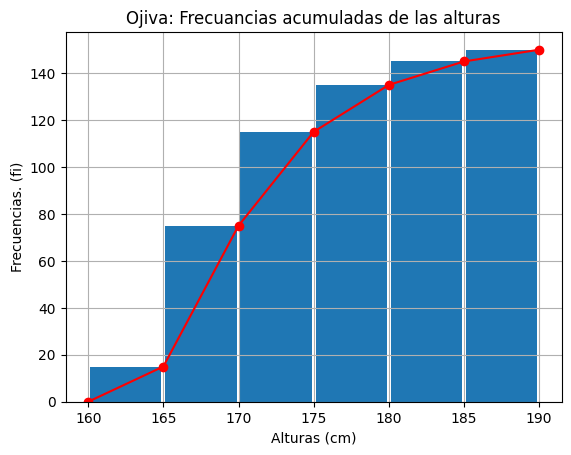

In [ ]:
fig3, ax3 = plt.subplots()
ax3.bar(df['Marca de Clase'], df['Frecuencia Acumulada. (fac)'], width=amplitud*0.95)

ojiva_x, ojiva_y = extremos, [0]+list(df['Frecuencia Acumulada. (fac)'])
ax3.plot(ojiva_x, ojiva_y, color='red', marker='o')

ax3.set_xlabel('Alturas (cm)'); ax3.set_ylabel('Frecuencias. (fi)'); ax3.set_title('Ojiva: Frecuancias acumuladas de las alturas'); ax3.grid()

In [ ]:
print(ojiva_x, ojiva_y, sep='\n')

[160, 165, 170, 175, 180, 185, 190]
[0, 15, 75, 115, 135, 145, 150]


#¿Que porcentaje de personas tiene menos de 178cm?

In [ ]:
def get_extremosYfrecuencia_acumulada(df:pd.DataFrame):
    return extremos, [0]+list(df['Frecuencia Acumulada. (fac)'])

#Interpolacion
En base a triangulos semejantes, $ACD = ABE → CD/AD = BE/AE$

#$$\frac {f_{ac_{k+1}}- f_{ac_k}} {a_{k+1} - a_k} =
\frac{N \frac{k}{(4|10|100)} - f_{ac_k}}{a_{valor}-a_k}$$


In [ ]:
# clave a_k < a_valor < a_k+1
# clave Nk/100 es la frecuencia acumulada de a_valor
# clave k es el nro de percentil o quartil o decil

Si es incognita $BE$ significa que conocemos $a_{valor}$.

Estamos buscando el nro de quartil centil o percentil en el que se encuentra $a_{valor}$

#$$\frac{f_{ac_{k+1}}-f_{ac}}{a_{k+1}-a_k}=\frac{x}{a_{valor}-a_k}$$

#$$x = \frac{f_{ac_{k+1}}-f_{ac}}{a_{k+1}-a_k}({a_{valor}-a_k}) $$


In [ ]:
def valor_to_intervalo(valor, extremos):
    """ Busca en extremos donde el valor de la variable 'valor' se encuentra """
    i = 0
    i_inf, i_sup = None, None
    while i < len(extremos) and extremos[i] <= valor:
        i += 1
    if i == len(extremos):
        print(f'El valor {valor} no se encuentra en los intervalos de los datos')
    else:
        i_inf, i_sup = i-1, i
    return i_inf, i_sup
print(valor_to_intervalo(178, extremos))

(3, 4)


In [ ]:
def interpolacion_BE(f_sig, f, a_sig, a, a_valor):
    """ Interpola asumiendo el segmento BE= (N*k/100-f_ac_k) incognita """
    return ( (f_sig - f) / (a_sig-a) ) * (a_valor - a)

Si es incognita $AE$ significa que:

*   conocemos $N$ cantidad de datos
*   conocemos $k$ nro de percentil decil o quartil
*   conocemos si es percentil decil o quartil

##Entonces con la fraccion $k$ podemos determinar la frecuencia acumulada que le corresponde a esa "fraccion" del conbjunto de datos

Estamos buscando el valor de  la variable que separa los datos

En $(\frac{k}{4|10|100})$ por debajo y $(1 - \frac{k}{4|10|100})$ por arriba

#$$\frac{f_{ac_{k+1}}-f_{ac}}{a_{k+1}-a_k}=
\frac{N\frac{k}{4|10|100} - f_{ac}}{x}$$

#$$x = \frac{a_{k+1}-a_k}{f_{ac_{k+1}}-f_{ac}}(N\frac{k}{4|10|100}-f_{ac}) $$


In [ ]:
# clave si Nk/100|10|4|2 es igual a f_ac_k+1 entonces el valor es a_k+1
# pero si en practica te das cuenta lo sacas sin calcular nada


In [ ]:
# tiene sentido porque los intervalos son [a_k, a_k+1)
# si fac_k+1 = N * f/100|..|2 entonces en a_k+1 se separa inferiormente y superiormente correctamente


In [ ]:
def frecuencia_acumulada_to_intervalo(f_buscada, frecuencias_acumuladas):
    i = 0
    i_inf, i_sup = -1,-1
    while i < len(frecuencias_acumuladas) and frecuencias_acumuladas[i] < f_buscada:
        i += 1
    if i == len(frecuencias_acumuladas):
        print(f'Error la frecuencia buscada es mayor que las frecuencias con estos datos')
    else:
        i_inf, i_sup = i-1, i
    return i_inf, i_sup

if __name__ == '__main__':
    extremos, f_acs = get_extremosYfrecuencia_acumulada(df)
    i_inf, i_sup = frecuencia_acumulada_to_intervalo(10, f_acs)
    print(extremos[i_inf], extremos[i_sup])
    print(f_acs[i_inf], f_acs[i_sup])

160 165
0 15


In [ ]:
def interpolacion_AE(f_sig, f, a_sig, a, N, k, partes):
    """
    N: cantidad de datos
    k: nro de partes buscadas
    partes: cuantas partes se dividen los datos
    """
    if partes > N:
        print(f'Error la cantidad de partes en la que se dividen los datos {partes} es mayor que la cantidad de datos {N}')
    if k > partes:
        print(f'Error el nro partes buscadas {k} es mayor que la cantidad de partes en la que se dividieron los datos {partes}')

    #print(a, a_sig, a_sig - a)
    #print(f, f_sig, f_sig-f)
    #print(N, k, partes, f, N * k/partes - f)
    return ( (a_sig - a) / (f_sig - f) ) * (N* k/partes - f)

if __name__ == '__main__':
    extremos, f_acs = get_extremosYfrecuencia_acumulada(df)
    N = f_acs[len(f_acs) - 1]
    k = 50
    f_bus = N * k / 100
    inf, sup = frecuencia_acumulada_to_intervalo(f_bus, f_acs)
    x = interpolacion_AE(f_acs[sup], f_acs[inf], extremos[sup], extremos[inf], N, k, 100)
    print(x)
    print(f'la altura que divide los datos en {(N*k/100)/N*100}% correspondiente a {N*k/100} personas es {extremos[inf] + x}cm')


5.0
la altura que divide los datos en 50.0% correspondiente a 75.0 personas es 170.0cm


In [ ]:
def percentil_to_valor(k, extremos, frecuencias_acumuladas):
    """   Determina el valor que separa los datos en k/100 y 1- k/100    """
    if k < 0 or k > 100:
        print(f'Error no existe percentil nro {k} debe estar entre 0 y 100')
    N = frecuencias_acumuladas[len(frecuencias_acumuladas)-1]
    frecuencia_buscada = N * k/100
    inf, sup = frecuencia_acumulada_to_intervalo(frecuencia_buscada, frecuencias_acumuladas)

    f, f_sig = frecuencias_acumuladas[inf], frecuencias_acumuladas[sup]
    a, a_sig = extremos[inf], extremos[sup]
    x = interpolacion_AE(f_sig, f, a_sig, a, N, k, 100)
    a_valor = a + x
    print(f'El valor de la variable que divide los datos en {(N*k/100)/N*100}% correspondiente a {N*k/100} datos es: {a_valor}')
    return a_valor


In [ ]:
def decil_to_valor(k, extremos, frecuencias_acumuladas):
    """   Determina el valor que separa los datos en k/10 y 1- k/10    """
    if k < 0 or k > 10:
        print(f'Error no existe quartil nro {k} debe estar entre 0 y 10')
    return percentil_to_valor(k*10, extremos, frecuencias_acumuladas)
def quartil_to_valor(k, extremos, frecuencias_acumuladas):
    """   Determina el valor que separa los datos en k/4 y 1- k/4    """
    if k < 0 or k > 4:
        print(f'Error no existe quartil nro {k} debe estar entre 0 y 4')
    return percentil_to_valor(k*25, extremos, frecuencias_acumuladas)
def mediana(k, extremos, frecuencias_acumuladas):
    """   Determina el valor que separa los datos en a lo sumo 50% abajo y 50% arriba     """
    return percentil_to_valor(50, extremos, frecuencias_acumuladas)

In [ ]:
if __name__ == '__main__':
    extremos, frecuencias_acumuladas = get_extremosYfrecuencia_acumulada(df)
    percentil_to_valor(2, extremos, frecuencias_acumuladas)

El valor de la variable que divide los datos en 2.0% correspondiente a 3.0 datos es: 161.0
